In [1]:
# mega notebook to combine Jelis and Samuel work

In [2]:
from landlab import RasterModelGrid
from landlab.plot.graph import plot_graph

<Axes: xlabel='x', ylabel='y'>

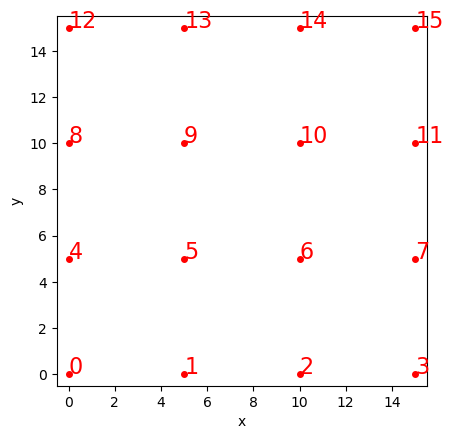

In [3]:
# create and visualize grid
spacing = 5.0
grid = RasterModelGrid((4, 4), xy_spacing=(spacing, spacing))

# grid.set_closed_boundaries_at_grid_edges(True, True, True, True)

plot_graph(grid, at="node")

In [4]:
# add temperature field
# and hardcode testing temperatures
temp = grid.add_ones("temp", at="node")
temp[(0),]=0
temp[(4, 1),] = -1
temp[(8, 5, 2),] = -2
temp[(12, 9, 6, 3),] = -3
temp[(10),] = -4
temp[(7, 11, 13, 14, 15),] = 5
grid.at_node["temp"] #sanity check

array([ 0., -1., -2., -3., -1., -2., -3.,  5., -2., -3., -4.,  5., -3.,
        5.,  5.,  5.])

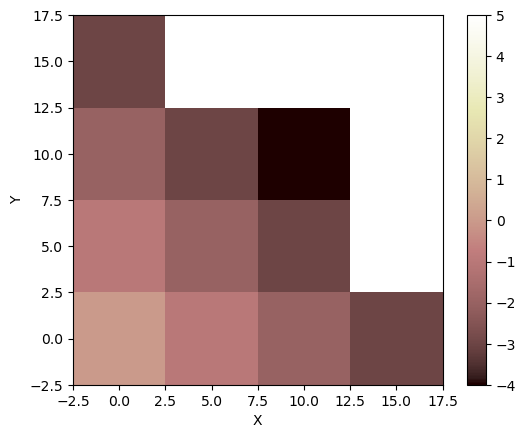

In [5]:
# visualize temperature distribution
grid.imshow(temp)

In [6]:
import numpy as np
is_clay = grid.add_field("is_clay", np.zeros(grid.shape), at="node")
grid.at_node["is_clay"][grid.at_node["temp"] < 5] = 1
grid.at_node["is_clay"]

array([1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0.])

In [7]:
def is_interior(grid, node):
    # determine whether node is on bottom or right boundary
    x, y = grid.x_of_node[node], grid.y_of_node[node]
    return (y > 0 and x != grid.shape[1])

In [8]:
# should be false
print(is_interior(grid, 1))

False


In [9]:
# should be true
print(is_interior(grid, 5))

True


In [10]:
def is_thawed(grid, node):
    return grid.at_node["temp"][node] >= 0        

In [11]:
# should return false
print(is_thawed(grid, 5))

False


In [12]:
# should return true
print(is_thawed(grid, 0))

True


In [13]:
def get_downright_node(grid, node):
    if is_interior(grid, node):
        x, y = grid.x_of_node[node], grid.y_of_node[node]
        #print(f"x={x}, y={y}")
        diag_node = grid.find_nearest_node([x+spacing, y-spacing]) # check this
        #print(f"diag node={diag_node}")
        return diag_node
    else:
        return ValueError("must be an interior node")

In [14]:
# 5 should return 2
print(get_downright_node(grid, 5))

2


In [15]:
# 0 should raise error
print(get_downright_node(grid, 0))

must be an interior node


In [16]:
# function 1: diag_is_soil
# only evaluating down-right diagonal
# assesses whether down-right is soil (or air)
def downright_is_open(grid, node):
    # check for not bottom or right boundary
    if is_interior(grid, node):
        diag_node = get_downright_node(grid, node)
        return grid.at_node['is_clay'][diag_node] == False
    else:
        return False # safety
        

In [17]:
# should return true
print(downright_is_open(grid, 10))

True


In [18]:
# should return false
print(downright_is_open(grid, 5))

False


In [19]:
# should raise error
print(downright_is_open(grid, 0))

False


In [20]:
def slide_node(grid, node, diag_node):
    # switch materials from clay to air and air to clay
    grid.at_node["is_clay"][node] = 0 # set current node to air
    grid.at_node["is_clay"][diag_node] = 1 # set down diag to clay
    
    #store this node's temp
    temp_temp = grid.at_node["temp"][node]

    # retrieve diagonal node's temp
    diag_temp = grid.at_node["temp"][diag_node]
    
    # switch the temperatures
    grid.at_node["temp"][node] = diag_temp
    grid.at_node["temp"][diag_node] = temp_temp

In [21]:
def slide_if_thawed(grid, node):
    if downright_is_open(grid, node) and is_thawed(grid,node):
        diag_node = get_downright_node(grid, node)
        slide_node(grid, node, diag_node)

In [22]:
# adjust temp manually for test
#grid.at_node["temp"][10] = 0

In [23]:
#slide_if_thawed(grid, 10)

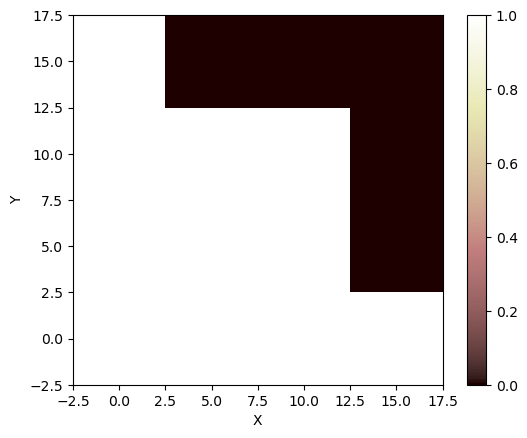

In [24]:
grid.imshow(is_clay)

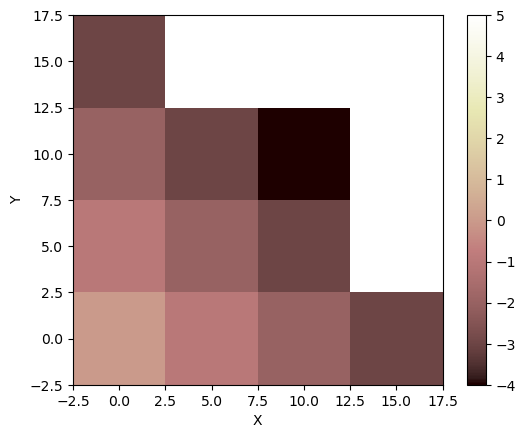

In [25]:
# visualize temperature distribution
grid.imshow(temp)

In [62]:
# prepare diffusion parameters
kappa = 1.5 * 1e-3
dt = 3600.0 * 24
n_time_steps = int(1e6)

In [65]:
# diffusion cell
for t in range(n_time_steps):
    temp[grid.at_node['is_clay'] == 0] = 15
    Tgrad = grid.calc_grad_at_link(temp)
    dTdt = kappa * grid.calc_flux_div_at_node(Tgrad)
    temp += dTdt * dt * (is_clay == 0)

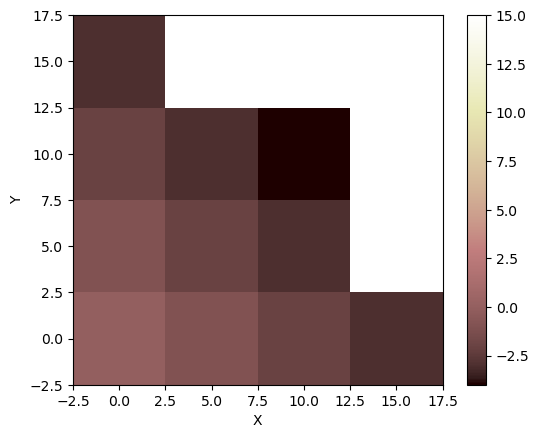

In [64]:
grid.imshow(temp)